JOINT TRAINING 

-Train na stari+novi

-Validation na stari + novi

-Test na novi podatoci

In [72]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import glob

In [73]:
stari_root = r"C:\stari podatoci\FEIT_eating_S05"
#ovde se site lugje od stari podatoci
subjects_stari = [d for d in os.listdir(stari_root) if os.path.isdir(os.path.join(stari_root, d))]

In [74]:
novi_root = r"C:\novi podatoci"
#site lujge od novi podatoci
subjects_novi = [d for d in os.listdir(novi_root) if os.path.isdir(os.path.join(novi_root, d))]

In [76]:
subjects_stari = sorted(subjects_stari)  # za stabilen split

stari_train = subjects_stari[:26]
stari_val  = subjects_stari[26:]

print("STARI TRAIN:", len(stari_train), stari_train)
print("STARI VAL:",   len(stari_val), stari_val)


STARI TRAIN: 26 ['Andrej Petrov', 'Angela Nastovska', 'Bojan Dimovski', 'Bojan Radovski', 'Damjan Srebrenkoski', 'Daniela Kovachovska', 'Filip Sivevski', 'Gorica Kovachovska', 'Ilina Kovachovska', 'Iva Jovanova', 'Ivana Kiprijanovska', 'Jovana Kostadinovska', 'Kristijan Milosheski', 'Marija Kovachovska', 'Marko Kostov', 'Matej Zlatkov', 'Monika Stoilkovska', 'Nikola Dimovski', 'Ognen Sekuloski', 'Sara Ilievska', 'Sara Kovachovska', 'Sashko Kovachovski', 'Stefan Dinushev', 'Stefanija Lazarovska', 'Tarek Abd El-Azis', 'Tomi Jovanov']
STARI VAL: 4 ['Tomi Nikoloski', 'Vasko Dimitrovski', 'Vedrana Petreska', 'Vladimir Petrov']


In [78]:
import hashlib

def stable_hash_split(subjects_novi, train_ratio=0.50, val_ratio=0.20):
    # train = [0, train_ratio)
    # val   = [train_ratio, train_ratio + val_ratio)
    # test  = остаток
    def score(name):
        h = hashlib.md5(name.encode("utf-8")).hexdigest()
        return int(h[:8], 16) / 0xFFFFFFFF

    train, val, test = [], [], []
    for s in subjects_novi:
        r = score(s)
        if r < train_ratio:
            train.append(s)
        elif r < train_ratio + val_ratio:
            val.append(s)
        else:
            test.append(s)
    return train, val, test


subjects_novi = sorted(subjects_novi)

novi_train, novi_val, novi_test = stable_hash_split(
    subjects_novi,
    train_ratio=0.50,
    val_ratio=0.20
)

print("NOVI TRAIN:", len(novi_train), novi_train)
print("NOVI VAL:",   len(novi_val), novi_val)
print("NOVI TEST:",  len(novi_test), novi_test)


NOVI TRAIN: 18 ['AnaI', 'AndrejCh', 'AndrejJ', 'AngelaK', 'DavidN', 'ElenaA', 'HristijanD', 'IrinaP', 'LeoJ', 'MarijaB', 'SandraM', 'SaraSh', 'StefanI', 'StefanIl', 'StefanijaK', 'StojanV', 'TeodorS', 'VladimirK']
NOVI VAL: 7 ['IvaI', 'MartinD', 'MilaP', 'PavelT', 'RistoK', 'SandraSh', 'SlavicaSh']
NOVI TEST: 7 ['AleksandraK', 'IvanP', 'KristinaK', 'MatrinI', 'MihaelaD', 'RezeartaLj', 'TeodoraD']


In [79]:
train_subjects = [("stari", s) for s in stari_train] + \
                 [("novi", s) for s in novi_train]

val_subjects   = [("stari", s) for s in stari_val] + \
                 [("novi", s) for s in novi_val]

test_subjects  = [("novi", s) for s in novi_test]


In [80]:
train_subjects

[('stari', 'Andrej Petrov'),
 ('stari', 'Angela Nastovska'),
 ('stari', 'Bojan Dimovski'),
 ('stari', 'Bojan Radovski'),
 ('stari', 'Damjan Srebrenkoski'),
 ('stari', 'Daniela Kovachovska'),
 ('stari', 'Filip Sivevski'),
 ('stari', 'Gorica Kovachovska'),
 ('stari', 'Ilina Kovachovska'),
 ('stari', 'Iva Jovanova'),
 ('stari', 'Ivana Kiprijanovska'),
 ('stari', 'Jovana Kostadinovska'),
 ('stari', 'Kristijan Milosheski'),
 ('stari', 'Marija Kovachovska'),
 ('stari', 'Marko Kostov'),
 ('stari', 'Matej Zlatkov'),
 ('stari', 'Monika Stoilkovska'),
 ('stari', 'Nikola Dimovski'),
 ('stari', 'Ognen Sekuloski'),
 ('stari', 'Sara Ilievska'),
 ('stari', 'Sara Kovachovska'),
 ('stari', 'Sashko Kovachovski'),
 ('stari', 'Stefan Dinushev'),
 ('stari', 'Stefanija Lazarovska'),
 ('stari', 'Tarek Abd El-Azis'),
 ('stari', 'Tomi Jovanov'),
 ('novi', 'AnaI'),
 ('novi', 'AndrejCh'),
 ('novi', 'AndrejJ'),
 ('novi', 'AngelaK'),
 ('novi', 'DavidN'),
 ('novi', 'ElenaA'),
 ('novi', 'HristijanD'),
 ('novi', 'Iri

In [81]:
val_subjects

[('stari', 'Tomi Nikoloski'),
 ('stari', 'Vasko Dimitrovski'),
 ('stari', 'Vedrana Petreska'),
 ('stari', 'Vladimir Petrov'),
 ('novi', 'IvaI'),
 ('novi', 'MartinD'),
 ('novi', 'MilaP'),
 ('novi', 'PavelT'),
 ('novi', 'RistoK'),
 ('novi', 'SandraSh'),
 ('novi', 'SlavicaSh')]

In [82]:
test_subjects

[('novi', 'AleksandraK'),
 ('novi', 'IvanP'),
 ('novi', 'KristinaK'),
 ('novi', 'MatrinI'),
 ('novi', 'MihaelaD'),
 ('novi', 'RezeartaLj'),
 ('novi', 'TeodoraD')]

In [ ]:
RENAME_MAP_OLD_TO_NEW = {
    "Accelerometer/Raw.X": "Accelerometer X",
    "Accelerometer/Raw.Y": "Accelerometer Y",

    "Gyroscope/Raw.X": "Gyroscope X",
    "Gyroscope/Raw.Y": "Gyroscope Y",

    "RotationVector/Raw.X": "Rotation Vector X",
    "RotationVector/Raw.Y": "Rotation Vector Y",

    # LeftTemple -> RightTemple (za da odgovara na modelot)
    "Nav/Raw.X[LeftTemple]": "Navigation Right Temple X",
    "Nav/Raw.Y[LeftTemple]": "Navigation Right Temple Y",
    "Prox/Raw[LeftTemple]": "Proximity Right Temple",
    "Nav/IQ[LeftTemple]": "Navigation Right Temple IQ",
    "Nav/Shutter[LeftTemple]": "Navigation Right Temple Shutter",
    "Nav/FrameAvg[LeftTemple]": "Navigation Right Temple Frame Avg",
}

FEATURE_COLS = [
    "Accelerometer X",
    "Accelerometer Y",
    "Gyroscope X",
    "Gyroscope Y",
    "Rotation Vector X",
    "Rotation Vector Y",
    "Navigation Right Temple X",
    "Navigation Right Temple Y",
    "Proximity Right Temple",
    "Navigation Right Temple IQ",
    "Navigation Right Temple Shutter",
    "Navigation Right Temple Frame Avg",
]


In [ ]:
#loader za stari podatoci so rename
import os, glob
import pandas as pd

def load_old_subject_dfs_renamed(stari_root, subject, rename_map):
    folder = os.path.join(stari_root, subject)
    files = sorted(glob.glob(os.path.join(folder, "*eating*.csv")))

    dfs = []
    for f in files:
        df = pd.read_csv(f)

        # metadata
        df["subject"] = subject
        df["source_path"] = f
        df["source_file"] = os.path.basename(f)

        # rename star -> nov
        df = df.rename(columns=rename_map)

        dfs.append(df)

    return dfs


In [85]:
#loader za novi podatoci
def load_new_subject_dfs(novi_root, subject):
    folder = os.path.join(novi_root, subject)
    files = sorted(glob.glob(os.path.join(folder, "*eating*.csv")))

    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["subject"] = subject
        df["source_path"] = f
        df["source_file"] = os.path.basename(f)
        dfs.append(df)

    return dfs


In [86]:
def load_split_dfs(subjects, stari_root, novi_root, rename_map_old):
    dfs = []
    for dom, s in subjects:
        if dom == "stari":
            dfs.extend(load_old_subject_dfs_renamed(stari_root, s, rename_map_old))
        elif dom == "novi":
            dfs.extend(load_new_subject_dfs(novi_root, s))
        else:
            raise ValueError(f"Unknown domain: {dom}")
    return dfs


In [87]:
train_dfs = load_split_dfs(train_subjects, stari_root, novi_root, RENAME_MAP_OLD_TO_NEW)
val_dfs   = load_split_dfs(val_subjects,   stari_root, novi_root, RENAME_MAP_OLD_TO_NEW)
test_dfs  = load_split_dfs(test_subjects,  stari_root, novi_root, RENAME_MAP_OLD_TO_NEW)


In [88]:
print(train_dfs[0].columns.tolist())


['SoftwareTimestamp', 'Timestamp', 'Accelerometer X', 'Accelerometer Y', 'Accelerometer/Raw.Z', 'Gyroscope X', 'Gyroscope Y', 'Gyroscope/Raw.Z', 'Magnetometer/Raw.X', 'Magnetometer/Raw.Y', 'Magnetometer/Raw.Z', 'Rotation Vector X', 'Rotation Vector Y', 'RotationVector/Raw.Z', 'RotationVector/Raw.W', 'Navigation Right Temple X', 'Navigation Right Temple Y', 'Proximity Right Temple', 'Pressure/Raw', 'Navigation Right Temple IQ', 'Navigation Right Temple Shutter', 'Navigation Right Temple Frame Avg', 'Annotations', 'subject', 'source_path', 'source_file']


In [89]:
def keep_only_needed_cols(df, feature_cols, label_col="Annotations", subject_col="subject"):
    keep_cols = feature_cols + [label_col, subject_col]

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    return df[keep_cols].copy()


In [90]:
train_dfs_final = [keep_only_needed_cols(df, FEATURE_COLS) for df in train_dfs]
val_dfs_final   = [keep_only_needed_cols(df, FEATURE_COLS) for df in val_dfs]
test_dfs_final  = [keep_only_needed_cols(df, FEATURE_COLS) for df in test_dfs]


In [91]:
print(train_dfs_final[0].columns.tolist())
print(train_dfs_final[0].shape)


['Accelerometer X', 'Accelerometer Y', 'Gyroscope X', 'Gyroscope Y', 'Rotation Vector X', 'Rotation Vector Y', 'Navigation Right Temple X', 'Navigation Right Temple Y', 'Proximity Right Temple', 'Navigation Right Temple IQ', 'Navigation Right Temple Shutter', 'Navigation Right Temple Frame Avg', 'Annotations', 'subject']
(26534, 14)


In [92]:
train_dfs_final

[       Accelerometer X  Accelerometer Y  Gyroscope X  Gyroscope Y  \
 0            -2.145937        -9.390872     1.341463     0.365854   
 1            -2.153123        -9.467512     0.000000     1.463415   
 2            -2.212998        -9.230405     0.000000     1.707317   
 3            -2.083667        -9.378896     0.000000     1.890244   
 4            -2.102827        -9.340576     0.548780     0.731707   
 ...                ...              ...          ...          ...   
 26529        -0.835862        -9.860295     0.121951    -0.670732   
 26530        -0.823887        -9.671089     0.060976    -0.426829   
 26531        -0.835862        -9.807605     0.975610    -0.243902   
 26532        -0.819097        -9.853110     0.670732    -0.121951   
 26533        -0.809517        -9.740544     0.426829    -0.243902   
 
        Rotation Vector X  Rotation Vector Y  Navigation Right Temple X  \
 0                  -2468             -10075                       -5.0   
 1      

In [ ]:
#Pravime windowing sega
#ova e funkcija za windowing
import numpy as np

def make_windows_from_dfs(
    dfs,
    feature_cols,
    label_col="Annotations",
    #eden window ima 150 posledovatelni sample(odnosno redovi)
    #bidejki tie se vremenski
    window_samples=150,
    #kolku se pomestuva window
    step_samples=25,
    label_strategy="majority"  # ili "last"
):
    X_list, y_list = [], []

    for df in dfs:
        X_raw = df[feature_cols].to_numpy(dtype=np.float32)
        y_raw = df[label_col].to_numpy()

        n = len(df)
        if n < window_samples:
            continue  

        for start in range(0, n - window_samples + 1, step_samples):
            end = start + window_samples

            Xw = X_raw[start:end]
            y_seg = y_raw[start:end]

            if label_strategy == "last":
                yw = y_seg[-1]
            else:  # majority vote
                vals, counts = np.unique(y_seg, return_counts=True)
                yw = vals[np.argmax(counts)]

            X_list.append(Xw)
            y_list.append(yw)

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)

    return X, y


In [114]:
#napravi windows
X_train, y_train = make_windows_from_dfs(
    train_dfs_final,
    feature_cols=FEATURE_COLS,
    label_col="Annotations",
    window_samples=150,
    step_samples=25
    #step_samples=100
)

X_val, y_val = make_windows_from_dfs(
    val_dfs_final,
    feature_cols=FEATURE_COLS,
    label_col="Annotations",
    window_samples=150,
    step_samples=25
    #step_samples=100
)

X_test, y_test = make_windows_from_dfs(
    test_dfs_final,
    feature_cols=FEATURE_COLS,
    label_col="Annotations",
    window_samples=150,
    step_samples=25
    #step_samples=100
)


In [115]:
print("TRAIN:", X_train.shape, y_train.shape)
print("VAL:  ", X_val.shape,   y_val.shape)
print("TEST: ", X_test.shape,  y_test.shape)


TRAIN: (51833, 150, 12) (51833,)
VAL:   (17053, 150, 12) (17053,)
TEST:  (8346, 150, 12) (8346,)


-Z SCORE SCALING, bidejki razmerite se mn razlicni mejgu features

-So delenje na vrednosta so std i mean se dobivaat vrednosti blisku do 0

-novata vrednost = (vrednost − prosek) / standardna devijacija


In [ ]:
import numpy as np

# mean i std po feature (preku site windows i site time steps)
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8


In [117]:
X_train_z = (X_train - mean) / std
X_val_z   = (X_val   - mean) / std
X_test_z  = (X_test  - mean) / std


In [118]:
#proverka
print("Train mean (≈0):", X_train_z.mean(axis=(0,1)))
print("Train std  (≈1):", X_train_z.std(axis=(0,1)))


Train mean (≈0): [ 2.2427957e-04 -3.3978543e-01  4.7537046e-07  2.3935021e-07
 -4.4528055e-03  2.5098814e-05  3.9276952e-06  1.5949445e-05
 -1.8593200e-03 -5.2317953e-01 -2.9940305e-02 -9.7569630e-02]
Train std  (≈1): [1.0003469  0.94007003 1.0004433  1.0004238  1.0010127  1.0026594
 1.0002154  1.0016596  0.9994402  0.859767   0.988785   1.0528612 ]


-TRENIRAM MODEL OD 0

In [ ]:
import tensorflow as tf

#1) deifiranje model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 12)),

    tf.keras.layers.Conv1D(64, 5, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(128, 5, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(256, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

# 2) compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)

# 3) callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6
    ),
]

# 4) train 
history = model.fit(
    X_train_z, y_train,
    validation_data=(X_val_z, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# 5) test (samo novi)
y_prob = model.predict(X_test_z).ravel()
y_pred = (y_prob >= 0.5).astype(int)


Epoch 1/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.7742 - auc: 0.8300 - loss: 0.4723 - val_accuracy: 0.8584 - val_auc: 0.9275 - val_loss: 0.3344 - learning_rate: 1.0000e-04
Epoch 2/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 30s 37ms/step - accuracy: 0.8770 - auc: 0.9392 - loss: 0.3009 - val_accuracy: 0.8637 - val_auc: 0.9293 - val_loss: 0.3265 - learning_rate: 1.0000e-04
Epoch 3/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - accuracy: 0.8868 - auc: 0.9489 - loss: 0.2760 - val_accuracy: 0.8692 - val_auc: 0.9338 - val_loss: 0.3191 - learning_rate: 1.0000e-04
Epoch 4/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.8929 - auc: 0.9545 - loss: 0.2590 - val_accuracy: 0.8651 - val_auc: 0.9338 - val_loss: 0.3224 - learning_rate: 1.0000e-04
Epoch 5/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.9000 - auc: 0.9596 - loss: 0.2459 - val_accuracy: 0.8712 - val_auc: 0.9356 - val_loss: 0.3199 - learning_rate: 1.0000e-04
Epoch 6/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/s

In [120]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))


[[3438  405]
 [ 708 3795]]
              precision    recall  f1-score   support

           0     0.8292    0.8946    0.8607      3843
           1     0.9036    0.8428    0.8721      4503

    accuracy                         0.8666      8346
   macro avg     0.8664    0.8687    0.8664      8346
weighted avg     0.8693    0.8666    0.8669      8346



In [121]:
y_prob = model.predict(X_test_z).ravel()
y_test.shape == y_prob.shape


261/261 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


True

In [122]:
#prsmetuvanje na  najdobar treshold
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(0.1, 0.9, 81)
best_t, best_f1 = 0, 0

for t in thresholds:
    y_p = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_p)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("Best threshold:", best_t)
print("Best F1:", best_f1)


Best threshold: 0.36
Best F1: 0.8821350762527234


In [ ]:
import tensorflow as tf


model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150, 12)),

    tf.keras.layers.Conv1D(64, 5, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(128, 5, padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(256, 3, padding="same", activation="relu"),
    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])


model2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
)


callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-6
    ),
]


history2 = model2.fit(
    X_train_z, y_train,
    validation_data=(X_val_z, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


y_prob = model2.predict(X_test_z).ravel()
y_pred = (y_prob >= 0.36).astype(int)




Epoch 1/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 31s 34ms/step - accuracy: 0.7611 - auc: 0.8163 - loss: 0.4913 - val_accuracy: 0.8645 - val_auc: 0.9280 - val_loss: 0.3290 - learning_rate: 1.0000e-04
Epoch 2/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.8780 - auc: 0.9388 - loss: 0.3016 - val_accuracy: 0.8634 - val_auc: 0.9316 - val_loss: 0.3429 - learning_rate: 1.0000e-04
Epoch 3/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8871 - auc: 0.9488 - loss: 0.2756 - val_accuracy: 0.8747 - val_auc: 0.9363 - val_loss: 0.3190 - learning_rate: 1.0000e-04
Epoch 4/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - accuracy: 0.8954 - auc: 0.9562 - loss: 0.2558 - val_accuracy: 0.8674 - val_auc: 0.9327 - val_loss: 0.3375 - learning_rate: 1.0000e-04
Epoch 5/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8985 - auc: 0.9579 - loss: 0.2508 - val_accuracy: 0.8701 - val_auc: 0.9322 - val_loss: 0.3447 - learning_rate: 1.0000e-04
Epoch 6/50
810/810 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/s

In [124]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))


[[3028  815]
 [ 367 4136]]
              precision    recall  f1-score   support

           0     0.8919    0.7879    0.8367      3843
           1     0.8354    0.9185    0.8750      4503

    accuracy                         0.8584      8346
   macro avg     0.8636    0.8532    0.8558      8346
weighted avg     0.8614    0.8584    0.8573      8346



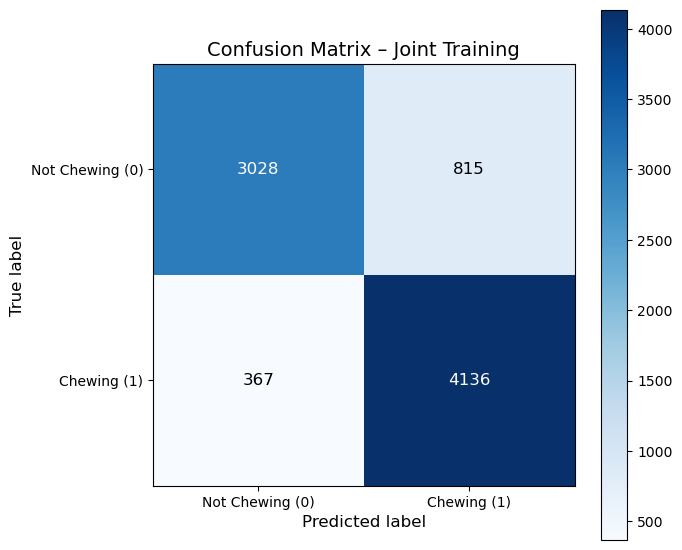

In [1]:
import numpy as np
import matplotlib.pyplot as plt

cm = np.array([
    [3028, 815],
    [367, 4136]
])

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm, cmap="Blues")

ax.set_title("Confusion Matrix – Joint Training", fontsize=14)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)

classes = ["Not Chewing (0)", "Chewing (1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

for i in range(2):
    for j in range(2):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            fontsize=12,
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()
